# Device Check

In [1]:
# ============================================================
# Project Information
# ============================================================
# Project : Vehicle Vision Assistant
# Model   : Qwen/Qwen3-VL-8B-Instruct
# Dataset : Paulescu/stanford_cars
# Method  : LoRA Fine-Tuning
# ============================================================

import platform
import torch

print("=" * 60)
print("Environment Information")
print("=" * 60)

print(f"Python          : {platform.python_version()}")
print(f"PyTorch         : {torch.__version__}")

print(f"CUDA Available  : {torch.cuda.is_available()}")
print(f"CUDA Version    : {torch.version.cuda}")

# ROCm builds report their HIP version here
print(f"ROCm Version    : {torch.version.hip}")

if torch.cuda.is_available():

    device = torch.cuda.current_device()
    props = torch.cuda.get_device_properties(device)

    print("-" * 60)
    print(f"GPU Name        : {props.name}")
    print(f"Compute Device  : {device}")
    print(f"Total VRAM      : {props.total_memory / 1024**3:.2f} GB")

print("=" * 60)

Environment Information
Python          : 3.12.3
PyTorch         : 2.10.0+rocm7.2.2.git40d237bf
CUDA Available  : True
CUDA Version    : None
ROCm Version    : 7.2.53211
------------------------------------------------------------
GPU Name        : AMD Instinct MI300X VF
Compute Device  : 0
Total VRAM      : 191.69 GB


In [2]:
!pip install trl --no-deps
!pip install peft --no-deps
!pip install -U qwen-vl-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 889.0/889.0 kB 21.9 MB/s  0:00:00

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 14.1 MB/s  0:00:00

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


# Imports

In [3]:
# Standard Library

import random

# Third-Party Libraries

import torch
import matplotlib.pyplot as plt

import datasets
import peft
import transformers
import trl

# Hugging Face

from datasets import load_dataset

from transformers import (
    AutoProcessor,
    Qwen3VLForConditionalGeneration,
)

# PEFT (LoRA)

from peft import (
    LoraConfig,
    get_peft_model,
)

# TRL

from trl import (
    SFTConfig,
    SFTTrainer,
)

# Qwen Utilities

from qwen_vl_utils import process_vision_info


SEED = 42

random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    
# Environment Information

print("=" * 60)
print("Environment")
print("=" * 60)
print(f"PyTorch       : {torch.__version__}")
print(f"Transformers  : {transformers.__version__}")
print(f"Datasets      : {datasets.__version__}")
print(f"PEFT          : {peft.__version__}")
print(f"TRL           : {trl.__version__}")
print("=" * 60)

Environment
PyTorch       : 2.10.0+rocm7.2.2.git40d237bf
Transformers  : 5.12.1
Datasets      : 4.8.4
PEFT          : 0.19.1
TRL           : 1.9.1


# Load Dataset


In [4]:
# Load Stanford Cars Dataset

dataset = load_dataset("Paulescu/stanford_cars")

print("-" * 60)
print("Dataset Summary")
print("-" * 60)

display(dataset)

print("\nDataset Features")
print("-" * 60)

display(dataset["train"].features)

print("\nNumber of Samples")
print("-" * 60)

print(f"Train : {len(dataset['train']):,}")
print(f"Test  : {len(dataset['test']):,}")

print("=" * 60)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/355M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/338M [00:00<?, ?B/s]

data/contrast-00000-of-00001.parquet:   0%|          | 0.00/346M [00:00<?, ?B/s]

data/gaussian_noise-00000-of-00002.parqu(…):   0%|          | 0.00/474M [00:00<?, ?B/s]

...

------------------------------------------------------------
Dataset Summary
------------------------------------------------------------


DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'maker', 'model', 'year'],
        num_rows: 6864
    })
    test: Dataset({
        features: ['image', 'label', 'maker', 'model', 'year'],
        num_rows: 6751
    })
    contrast: Dataset({
        features: ['image', 'label', 'maker', 'model', 'year'],
        num_rows: 8041
    })
    gaussian_noise: Dataset({
        features: ['image', 'label', 'maker', 'model', 'year'],
        num_rows: 8041
    })
    impulse_noise: Dataset({
        features: ['image', 'label', 'maker', 'model', 'year'],
        num_rows: 8041
    })
    jpeg_compression: Dataset({
        features: ['image', 'label', 'maker', 'model', 'year'],
        num_rows: 8041
    })
    motion_blur: Dataset({
        features: ['image', 'label', 'maker', 'model', 'year'],
        num_rows: 8041
    })
    pixelate: Dataset({
        features: ['image', 'label', 'maker', 'model', 'year'],
        num_rows: 8041
    })
    spatter: Dataset({
    


Dataset Features
------------------------------------------------------------


{'image': Image(mode=None, decode=True),
 'label': ClassLabel(names=['AM General Hummer SUV 2000', 'Acura RL Sedan 2012', 'Acura TL Sedan 2012', 'Acura TL Type-S 2008', 'Acura TSX Sedan 2012', 'Acura Integra Type R 2001', 'Acura ZDX Hatchback 2012', 'Aston Martin V8 Vantage Convertible 2012', 'Aston Martin V8 Vantage Coupe 2012', 'Aston Martin Virage Convertible 2012', 'Aston Martin Virage Coupe 2012', 'Audi RS 4 Convertible 2008', 'Audi A5 Coupe 2012', 'Audi TTS Coupe 2012', 'Audi R8 Coupe 2012', 'Audi V8 Sedan 1994', 'Audi 100 Sedan 1994', 'Audi 100 Wagon 1994', 'Audi TT Hatchback 2011', 'Audi S6 Sedan 2011', 'Audi S5 Convertible 2012', 'Audi S5 Coupe 2012', 'Audi S4 Sedan 2012', 'Audi S4 Sedan 2007', 'Audi TT RS Coupe 2012', 'BMW ActiveHybrid 5 Sedan 2012', 'BMW 1 Series Convertible 2012', 'BMW 1 Series Coupe 2012', 'BMW 3 Series Sedan 2012', 'BMW 3 Series Wagon 2012', 'BMW 6 Series Convertible 2007', 'BMW X5 SUV 2007', 'BMW X6 SUV 2012', 'BMW M3 Coupe 2012', 'BMW M5 Sedan 2010', 'B


Number of Samples
------------------------------------------------------------
Train : 6,864
Test  : 6,751


# Show Sample

------------------------------------------------------------
Sample Information
------------------------------------------------------------
Maker : AM
Model : General Hummer SUV
Year  : 2000
------------------------------------------------------------


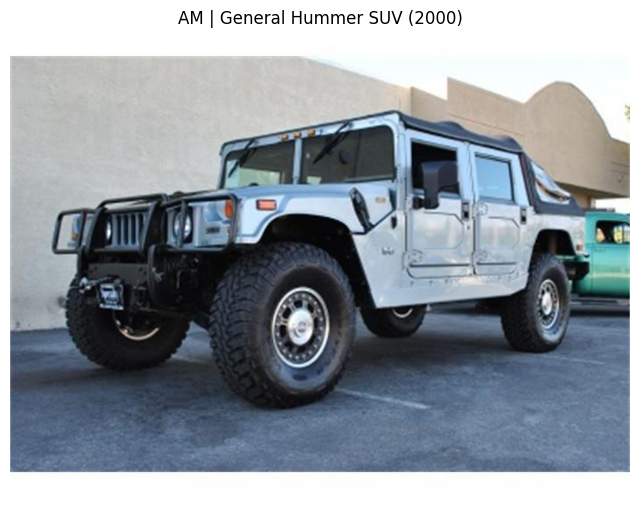

In [5]:
# Display Sample from Training Dataset

sample = dataset["train"][0]

print("-" * 60)
print("Sample Information")
print("-" * 60)

print(f"Maker : {sample['maker']}")
print(f"Model : {sample['model']}")
print(f"Year  : {sample['year']}")

print("-" * 60)


plt.figure(figsize=(8, 8))
plt.imshow(sample["image"])
plt.title(f"{sample['maker']} | {sample['model']} ({sample['year']})")
plt.axis("off")
plt.show()

# Dataset Statistics

In [6]:
train_size = len(dataset["train"])
test_size = len(dataset["test"])

makers = sorted(set(dataset["train"]["maker"]))
models = sorted(set(dataset["train"]["model"]))
years = sorted(set(dataset["train"]["year"]))

print("=" * 60)
print("Dataset Statistics")
print("=" * 60)

print(f"Training Samples : {train_size:,}")
print(f"Testing Samples  : {test_size:,}")
print(f"Manufacturers    : {len(makers)}")
print(f"Vehicle Models   : {len(models)}")
print(f"Production Years : {len(years)}")

print("-" * 60)
print(f"Years : {years}")

print("-" * 60)
print("Manufacturers:")
print(makers)

print("=" * 60)

Dataset Statistics
Training Samples : 6,864
Testing Samples  : 6,751
Manufacturers    : 49
Vehicle Models   : 189
Production Years : 16
------------------------------------------------------------
Years : ['1991', '1993', '1994', '1997', '1998', '1999', '2000', '2001', '2002', '2006', '2007', '2008', '2009', '2010', '2011', '2012']
------------------------------------------------------------
Manufacturers:
['AM', 'Acura', 'Aston', 'Audi', 'BMW', 'Bentley', 'Bugatti', 'Buick', 'Cadillac', 'Chevrolet', 'Chrysler', 'Daewoo', 'Dodge', 'Eagle', 'FIAT', 'Ferrari', 'Fisker', 'Ford', 'GMC', 'Geo', 'HUMMER', 'Honda', 'Hyundai', 'Infiniti', 'Isuzu', 'Jaguar', 'Jeep', 'Lamborghini', 'Land', 'Lincoln', 'MINI', 'Maybach', 'Mazda', 'McLaren', 'Mercedes-Benz', 'Mitsubishi', 'Nissan', 'Plymouth', 'Porsche', 'Ram', 'Rolls-Royce', 'Scion', 'Spyker', 'Suzuki', 'Tesla', 'Toyota', 'Volkswagen', 'Volvo', 'smart']


In [7]:
# ============================================================
# Dataset Labels
# ============================================================

label_names = dataset["train"].features["label"].names

print("=" * 60)
print("Dataset Labels")
print("=" * 60)
print(f"Number of Classes : {len(label_names)}")
print(f"First Label       : {label_names[0]}")
print("=" * 60)

Dataset Labels
Number of Classes : 196
First Label       : AM General Hummer SUV 2000


# Load Model

In [8]:
# Configuration

MODEL_NAME = "Qwen/Qwen3-VL-8B-Instruct"

DTYPE = torch.bfloat16
DEVICE_MAP = "auto"

print("-" * 60)
print("Model Configuration")
print("-" * 60)
print(f"Model      : {MODEL_NAME}")
print(f"Data Type  : {DTYPE}")
print(f"Device Map : {DEVICE_MAP}")
print("-" * 60)

------------------------------------------------------------
Model Configuration
------------------------------------------------------------
Model      : Qwen/Qwen3-VL-8B-Instruct
Data Type  : torch.bfloat16
Device Map : auto
------------------------------------------------------------


In [9]:
# Load Processor & Model

processor = AutoProcessor.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
)

model = Qwen3VLForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=DTYPE,
    device_map=DEVICE_MAP,
    trust_remote_code=True,
)

print("-" * 60)
print("Model Loaded Successfully")
print("-" * 60)
print(f"Model Type      : {model.config.model_type}")
print(f"Vocabulary Size : {processor.tokenizer.vocab_size:,}")
print("-" * 60)

preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

------------------------------------------------------------
Model Loaded Successfully
------------------------------------------------------------
Model Type      : qwen3_vl
Vocabulary Size : 151,643
------------------------------------------------------------


In [10]:
# Training Prompts

PROMPTS = [
    "Identify the vehicle in this image.",
    "What car is shown in the image?",
    "Recognize the manufacturer, model, and year of this vehicle.",
    "Identify this vehicle as accurately as possible.",
]

print("-" * 60)
print("Training Prompts")
print("-" * 60)

for i, prompt in enumerate(PROMPTS, start=1):
    print(f"{i}. {prompt}")

print("-" * 60)

------------------------------------------------------------
Training Prompts
------------------------------------------------------------
1. Identify the vehicle in this image.
2. What car is shown in the image?
3. Recognize the manufacturer, model, and year of this vehicle.
4. Identify this vehicle as accurately as possible.
------------------------------------------------------------


# LoRA Config

In [11]:
# ============================================================
# LoRA Configuration
# ============================================================

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
)

print("-" * 60)
print("LoRA Configuration")
print("-" * 60)
print(f"Rank (r)        : {lora_config.r}")
print(f"LoRA Alpha      : {lora_config.lora_alpha}")
print(f"LoRA Dropout    : {lora_config.lora_dropout}")
print(f"Target Modules  : {len(lora_config.target_modules)}")
print("-" * 60)

------------------------------------------------------------
LoRA Configuration
------------------------------------------------------------
Rank (r)        : 16
LoRA Alpha      : 32
LoRA Dropout    : 0.05
Target Modules  : 7
------------------------------------------------------------


In [12]:
# ============================================================
# Apply LoRA
# ============================================================

model = get_peft_model(model, lora_config)

print("=" * 60)
print("LoRA Applied Successfully")
print("=" * 60)

model.print_trainable_parameters()

print("=" * 60)

LoRA Applied Successfully
trainable params: 43,646,976 || all params: 8,810,770,672 || trainable%: 0.4954


# SFTConfig

In [13]:
# Training Configuration

OUTPUT_DIR = "./qwen3vl-car-lora"

training_args = SFTConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=2,
    learning_rate=2e-4,
    bf16=True,
    logging_steps=10,
    save_strategy="epoch",
    remove_unused_columns=False,
    report_to="none",
)

print("=" * 60)
print("Training Configuration")
print("=" * 60)
print(f"Epochs             : {training_args.num_train_epochs}")
print(f"Batch Size         : {training_args.per_device_train_batch_size}")
print(f"Gradient Accum     : {training_args.gradient_accumulation_steps}")
print(f"Learning Rate      : {training_args.learning_rate}")
print(f"Output Directory   : {training_args.output_dir}")
print("=" * 60)

Training Configuration
Epochs             : 3
Batch Size         : 4
Gradient Accum     : 2
Learning Rate      : 0.0002
Output Directory   : ./qwen3vl-car-lora


In [14]:
# Data Collator

def collate_fn(examples):

    texts = []
    images = []

    for example in examples:

        prompt = random.choice(PROMPTS)
        answer = label_names[example["label"]]

        conversation = [
            {
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "image": example["image"],
                    },
                    {
                        "type": "text",
                        "text": prompt,
                    },
                ],
            },
            {
                "role": "assistant",
                "content": [
                    {
                        "type": "text",
                        "text": answer,
                    }
                ],
            },
        ]

        text = processor.apply_chat_template(
            conversation,
            tokenize=False,
            add_generation_prompt=False,
        )

        image_inputs, _ = process_vision_info(conversation)

        texts.append(text)
        images.append(image_inputs)

    batch = processor(
        text=texts,
        images=images,
        padding=True,
        return_tensors="pt",
    )

    labels = batch["input_ids"].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100

    batch["labels"] = labels

    return batch

print("✓ Custom data collator is ready.")

✓ Custom data collator is ready.


# Trainer

In [15]:
# Initialize SFT Trainer

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    processing_class=processor,
    data_collator=collate_fn,
)

print("=" * 60)
print("SFTTrainer Initialized Successfully")
print("=" * 60)
print(f"Training Samples : {len(dataset['train']):,}")
print(f"Training Epochs  : {training_args.num_train_epochs}")
print("=" * 60)

SFTTrainer Initialized Successfully
Training Samples : 6,864
Training Epochs  : 3


In [16]:
# ============================================================
# Verify Data Collator
# ============================================================

batch = collate_fn([dataset["train"][0]])

print("=" * 60)
print("Batch Information")
print("=" * 60)

for key, value in batch.items():
    if isinstance(value, torch.Tensor):
        print(f"{key:<20} {tuple(value.shape)}")
    else:
        print(f"{key:<20} {type(value)}")

print("=" * 60)

Batch Information
input_ids            (1, 404)
attention_mask       (1, 404)
mm_token_type_ids    (1, 404)
pixel_values         (1496, 1536)
image_grid_thw       (1, 3)
labels               (1, 404)


In [17]:
#cheack for divice 
!rocm-smi



============================================ ROCm System Management Interface ============================================
====================================================== Concise Info ======================================================
Device  Node  IDs              Temp        Power     Partitions          SCLK    MCLK     Fan  Perf  PwrCap  VRAM%  GPU%  
              (DID,     GUID)  (Junction)  (Socket)  (Mem, Compute, ID)                                                   
0       2     0x74b5,   21947  52.0°C      212.0W    NPS1, SPX, 0        654Mhz  1100Mhz  0%   auto  750.0W  8%     2%    
================================================== End of ROCm SMI Log ===================================================


# Start Fine-Tuning

In [ ]:
import threading
import time
import subprocess

def monitor_gpu():
    while True:
        print("\n" + "=" * 80)
        subprocess.run(["rocm-smi"])
        time.sleep(60)

threading.Thread(target=monitor_gpu, daemon=True).start()

trainer.train()

print(trainer.state)




============================================ ROCm System Management Interface ============================================
====================================================== Concise Info ======================================================
Device  Node  IDs              Temp        Power     Partitions          SCLK     MCLK    Fan  Perf  PwrCap  VRAM%  GPU%  
              (DID,     GUID)  (Junction)  (Socket)  (Mem, Compute, ID)                                                   
0       2     0x74b5,   21947  54.0°C      214.0W    NPS1, SPX, 0        2098Mhz  900Mhz  0%   auto  750.0W  10%    0%    
================================================== End of ROCm SMI Log ===================================================


Step,Training Loss
10,10.014717
20,7.315488
30,7.097593





============================================= ROCm System Management Interface =============================================
======================================================= Concise Info =======================================================
Device  Node  IDs              Temp        Power     Partitions          SCLK     MCLK     Fan  Perf  PwrCap  VRAM%  GPU%  
              (DID,     GUID)  (Junction)  (Socket)  (Mem, Compute, ID)                                                    
0       2     0x74b5,   21947  60.0°C      333.0W    NPS1, SPX, 0        2093Mhz  1300Mhz  0%   auto  750.0W  12%    100%  
=================================================== End of ROCm SMI Log ====================================================



============================================= ROCm System Management Interface =============================================
======================================================= Concise Info =====================================================

# Save LoRA Adapter

In [ ]:
# ============================================================
# Save LoRA Adapter
# ============================================================

trainer.save_model(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)

print("=" * 60)
print("LoRA Adapter Saved Successfully")
print(f"Path : {OUTPUT_DIR}")
print("=" * 60)

In [ ]:
# ============================================================
# Select Test Samples
# ============================================================

NUM_SAMPLES = 5

test_samples = random.sample(
    range(len(dataset["test"])),
    NUM_SAMPLES,
)

print("=" * 60)
print(f"Testing on {NUM_SAMPLES} Random Images")
print("=" * 60)

In [ ]:
# ============================================================
# Text Normalization
# ============================================================

import re

def normalize_text(text):
    """
    Normalize text before comparison.
    """

    text = text.lower().strip()

    # Remove punctuation
    text = re.sub(r"[^\w\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text

In [ ]:
# ============================================================
# Test Fine-Tuned Model
# ============================================================

correct = 0
manufacturer_score = 0
model_score = 0
year_score = 0
overall_score = 0
for i, idx in enumerate(test_samples, start=1):

    sample = dataset["test"][idx]

    image = sample["image"]
    ground_truth = label_names[sample["label"]]

    conversation = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image,
                },
                {
                    "type": "text",
                    "text": "Identify the manufacturer, model, and year of this vehicle.",
                },
            ],
        }
    ]

    text = processor.apply_chat_template(
        conversation,
        tokenize=False,
        add_generation_prompt=True,
    )

    image_inputs, _ = process_vision_info(conversation)

    inputs = processor(
        text=[text],
        images=image_inputs,
        return_tensors="pt",
    ).to(model.device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=30,
        )

    generated_ids = output[:, inputs.input_ids.shape[1]:]

    prediction = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True,
    )[0].strip()

    prediction_clean = normalize_text(prediction)
    ground_truth_clean = normalize_text(ground_truth)
    gt_manufacturer, gt_model, gt_year = parse_vehicle(ground_truth)

    pred_manufacturer, pred_model, pred_year = parse_vehicle(prediction)

    manufacturer_correct = pred_manufacturer == gt_manufacturer
    model_correct = pred_model == gt_model
    year_correct = pred_year == gt_year

    sample_correct = (
        manufacturer_correct
        and model_correct
        and year_correct
    )

    manufacturer_score += manufacturer_correct
    model_score += model_correct
    year_score += year_correct
    overall_score += sample_correct

    is_correct = prediction_clean == ground_truth_clean

    if is_correct:
        correct += 1

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Sample {i}")
    plt.show()

    print("=" * 60)
    print(f"Ground Truth : {ground_truth}")
    print(f"Prediction   : {prediction}")
    print(f"Correct      : {is_correct}")
    print("=" * 60)
    print("=" * 60)
    print(f"Ground Truth : {ground_truth}")
    print(f"Prediction   : {prediction}")
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

    print("=" * 60)
    print(f"Ground Truth : {ground_truth}")
    print(f"Prediction   : {prediction}")

    print(f"Manufacturer : {'PASS' if manufacturer_correct else 'FAIL'}")
    print(f"Model        : {'PASS' if model_correct else 'FAIL'}")
    print(f"Year         : {'PASS' if year_correct else 'FAIL'}")

    print(f"Overall      : {'PASS' if sample_correct else 'FAIL'}")
    print("=" * 60)

    if is_correct:
        print("Result       : PASS")
    else:
        print("Result       : FAIL")

    print("=" * 60)

In [ ]:
# ============================================================
# Inference Summary
# ============================================================

accuracy = correct / NUM_SAMPLES * 100

print("=" * 60)
print("Inference Summary")
print("=" * 60)
print(f"Correct Predictions : {correct}/{NUM_SAMPLES}")
print(f"Accuracy            : {accuracy:.2f}%")
print("=" * 60)